===== ESTADÍSTICAS INFERENCIALES =====
Media Horas: 4.84 | Media Puntaje: 48.55
Mediana Horas: 4.81 | Mediana Puntaje: 48.69
Moda Horas: 1.07 | Moda Puntaje: 12.09
Varianza Horas: 1.86 | Varianza Puntaje: 190.59
Desviación Estándar Horas: 1.36 | Desviación Puntaje: 13.81
Coeficiente de Correlación: 0.940


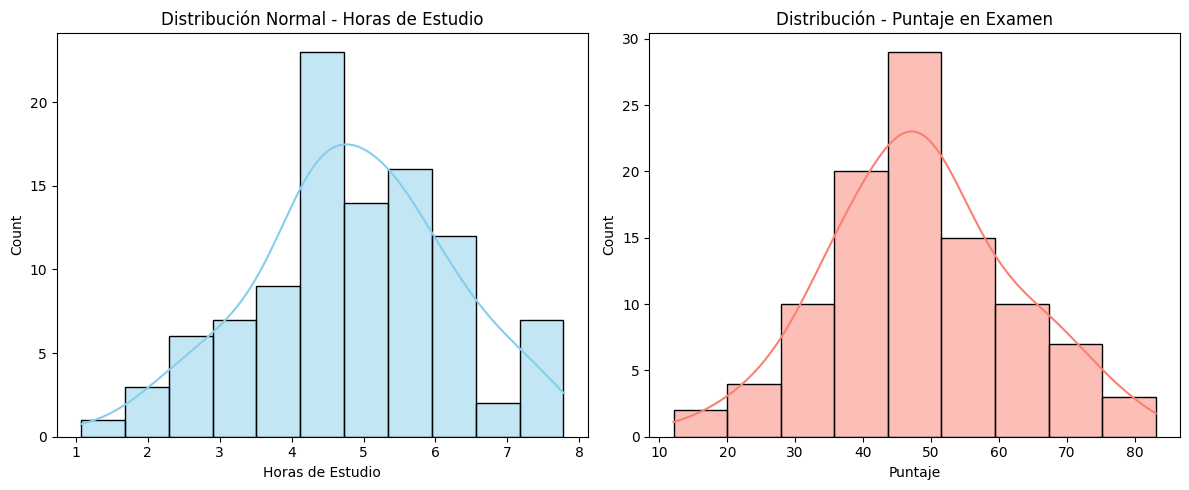

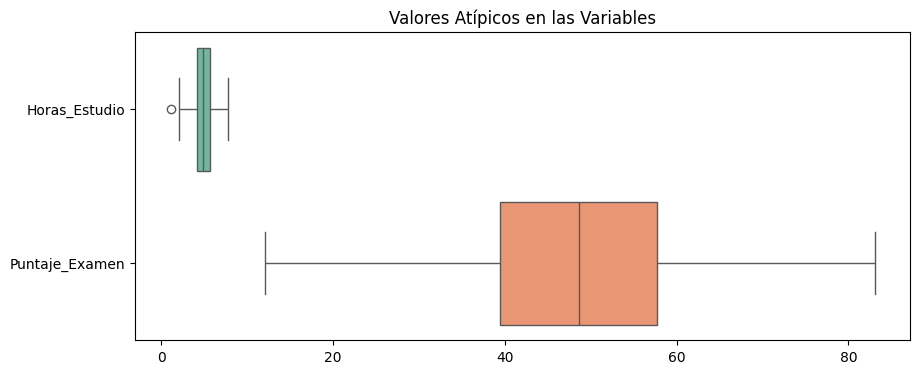

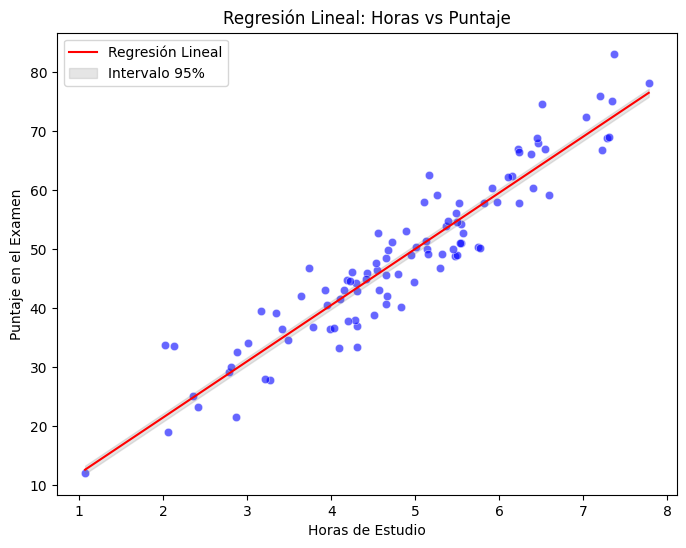


===== PRUEBA DE CORRELACIÓN (r de Pearson) =====
t = 0.940, p-valor = 0.00000
✅ Existe correlación significativa entre las variables.


In [ ]:
# ===========================================
# 📊 Análisis Estadístico Inferencial en Python
# ===========================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ===========================================
# 1️⃣ Crear dataset simulado (realista)
# ===========================================
np.random.seed(42)
n = 100
horas_estudio = np.random.normal(5, 1.5, n)  # media=5h, desviación=1.5
puntaje_examen = 10 * horas_estudio + np.random.normal(0, 5, n)  # relación lineal con ruido

# Crear DataFrame
data = pd.DataFrame({
    "Horas_Estudio": horas_estudio,
    "Puntaje_Examen": puntaje_examen
})

# ===========================================
# 2️⃣ Estadística descriptiva
# ===========================================
media_horas = data["Horas_Estudio"].mean()
media_puntaje = data["Puntaje_Examen"].mean()

mediana_horas = data["Horas_Estudio"].median()
mediana_puntaje = data["Puntaje_Examen"].median()

moda_horas = data["Horas_Estudio"].mode()[0]
moda_puntaje = data["Puntaje_Examen"].mode()[0]

var_horas = data["Horas_Estudio"].var()
var_puntaje = data["Puntaje_Examen"].var()

desv_horas = data["Horas_Estudio"].std()
desv_puntaje = data["Puntaje_Examen"].std()

correlacion = data["Horas_Estudio"].corr(data["Puntaje_Examen"])

print("===== ESTADÍSTICAS INFERENCIALES =====")
print(f"Media Horas: {media_horas:.2f} | Media Puntaje: {media_puntaje:.2f}")
print(f"Mediana Horas: {mediana_horas:.2f} | Mediana Puntaje: {mediana_puntaje:.2f}")
print(f"Moda Horas: {moda_horas:.2f} | Moda Puntaje: {moda_puntaje:.2f}")
print(f"Varianza Horas: {var_horas:.2f} | Varianza Puntaje: {var_puntaje:.2f}")
print(f"Desviación Estándar Horas: {desv_horas:.2f} | Desviación Puntaje: {desv_puntaje:.2f}")
print(f"Coeficiente de Correlación: {correlacion:.3f}")

# ===========================================
# 3️⃣ Gráficas de distribución
# ===========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data["Horas_Estudio"], kde=True, color='skyblue')
plt.title("Distribución Normal - Horas de Estudio")
plt.xlabel("Horas de Estudio")

plt.subplot(1, 2, 2)
sns.histplot(data["Puntaje_Examen"], kde=True, color='salmon')
plt.title("Distribución - Puntaje en Examen")
plt.xlabel("Puntaje")
plt.tight_layout()
plt.show()

# ===========================================
# 4️⃣ Detección de valores atípicos (Boxplot)
# ===========================================
plt.figure(figsize=(10,4))
sns.boxplot(data=data, orient='h', palette='Set2')
plt.title("Valores Atípicos en las Variables")
plt.show()

# ===========================================
# 5️⃣ Regresión lineal simple
# ===========================================
slope, intercept, r, p, std_err = stats.linregress(data["Horas_Estudio"], data["Puntaje_Examen"])

# Línea de regresión
x = np.linspace(data["Horas_Estudio"].min(), data["Horas_Estudio"].max(), 100)
y_pred = intercept + slope * x

# Intervalos de confianza (95%)
ci = 1.96 * std_err
y_inf = y_pred - ci
y_sup = y_pred + ci

plt.figure(figsize=(8,6))
sns.scatterplot(x="Horas_Estudio", y="Puntaje_Examen", data=data, color='blue', alpha=0.6)
plt.plot(x, y_pred, color='red', label='Regresión Lineal')
plt.fill_between(x, y_inf, y_sup, color='gray', alpha=0.2, label='Intervalo 95%')
plt.title("Regresión Lineal: Horas vs Puntaje")
plt.xlabel("Horas de Estudio")
plt.ylabel("Puntaje en el Examen")
plt.legend()
plt.show()

# ===========================================
# 6️⃣ Prueba inferencial (correlación significativa)
# ===========================================
t_stat, p_valor = stats.pearsonr(data["Horas_Estudio"], data["Puntaje_Examen"])
print("\n===== PRUEBA DE CORRELACIÓN (r de Pearson) =====")
print(f"t = {t_stat:.3f}, p-valor = {p_valor:.5f}")
if p_valor < 0.05:
    print("✅ Existe correlación significativa entre las variables.")
else:
    print("❌ No hay correlación significativa.")